# cellAdmix Python SpatialData integration

This notebook shows a SpatialData-first workflow for the Xenium pancreas example. SpatialData owns the Python-side object model, cell annotations, spatial labels, and downstream corrected counts. cellAdmix still uses the original Xenium bundle path so the C++ backend can stream the full molecule table and read stain images without materializing all transcripts in Python memory.

Current `spatialdata`, `spatialdata-io`, and `spatialdata-plot` releases require Python 3.11 or newer. Use a Python 3.11+ environment for this notebook.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
import spatialdata_io as sd_io
import spatialdata_plot  # registers the SpatialData .pl plotting accessor
from sklearn.neighbors import NearestNeighbors

from celladmix import (
    add_corrected_counts_to_spatialdata,
    add_fit_to_spatialdata,
    from_spatialdata,
    read_annotation,
)

Download the 10x Genomics pancreas bundle from https://www.10xgenomics.com/datasets/ffpe-human-pancreas-with-xenium-multimodal-cell-segmentation-1-standard, or directly with `curl -O https://cf.10xgenomics.com/samples/xenium/2.0.0/Xenium_V1_human_Pancreas_FFPE/Xenium_V1_human_Pancreas_FFPE_outs.zip`, then unzip it into `data/`.

The example annotation file used here is intentionally lightweight and only serves to keep the tutorial short.

In [2]:
data_dir = Path("data")
annotation_file = Path("annotations/annotation.csv.gz")
output_dir = Path("out_python_spatialdata")

`spatialdata_io.xenium()` reads the Xenium bundle into a SpatialData object. Here we request a lightweight read: the SpatialData table and label image are loaded, while cellAdmix later streams molecules and stain images directly from the original bundle. In a typical workflow, cell annotations would already be stored in the SpatialData table after clustering and annotation. For this tutorial, we load the example annotation and attach it to the table explicitly.

In [3]:
sdata = sd_io.xenium(data_dir, transcripts=False, morphology_mip=False, morphology_focus=False,
                      aligned_images=False, nucleus_labels=False, n_jobs=10)
table_name = next(iter(sdata.tables.keys()))
adata = sdata.tables[table_name]

annotation = read_annotation(annotation_file, annotation_col="merged_annotation")
adata.obs["cell_type"] = pd.Categorical(annotation.reindex(adata.obs_names.astype(str)))
adata.obs["cell_type"].value_counts(dropna=False)

cell_type
Exocrine epithelial        36329
Ductal/tumor epithelial    29986
Fibroblast / CAF           28366
Immune                     19251
NaN                        14979
Endothelial                 7026
Mural / pericyte            2553
Endocrine                   2212
Name: count, dtype: int64

The first spatial check shows the full tissue at cell level. Instead of rendering the full `cell_labels` raster, which can be slow and makes notebook output large, we plot cell centroids from the SpatialData table and color them by the annotation stored in `adata.obs`.

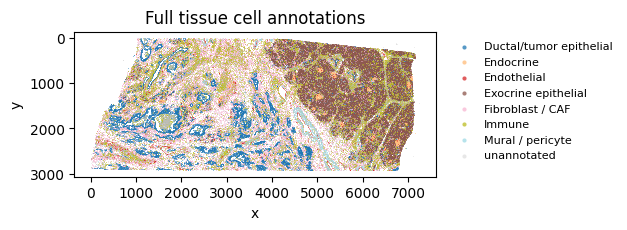

In [4]:
def plot_cell_spatial(adata, color, title, *, point_size=0.25, ax=None):
    xy = np.asarray(adata.obsm["spatial"])
    values = adata.obs[color]
    categories = pd.Categorical(values)
    if ax is None:
        _, ax = plt.subplots(figsize=(6.4, 6.4))
    palette = plt.get_cmap("tab20", max(1, len(categories.categories)))
    for i, category in enumerate(categories.categories):
        mask = np.asarray(categories == category)
        if mask.any():
            ax.scatter(xy[mask, 0], xy[mask, 1], s=point_size, color=palette(i),
                       alpha=0.75, linewidths=0, rasterized=True, label=str(category))
    missing = pd.isna(values).to_numpy()
    if missing.any():
        ax.scatter(xy[missing, 0], xy[missing, 1], s=point_size, color="#bdbdbd",
                   alpha=0.35, linewidths=0, rasterized=True, label="unannotated")
    ax.set_aspect("equal", adjustable="box")
    ax.invert_yaxis()
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(title)
    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), frameon=False,
              fontsize=8, markerscale=6)
    ax.figure.tight_layout()
    return ax

plot_cell_spatial(adata, "cell_type", "Full tissue cell annotations")
plt.show()

`from_spatialdata()` constructs a cellAdmix dataset using annotations from the SpatialData table. The explicit `xenium_dir` argument is intentional: current SpatialData objects do not reliably preserve enough original-bundle path information for high-throughput molecule streaming and stain-image discovery.

In [5]:
ds = from_spatialdata(sdata, xenium_dir=data_dir, output_dir=output_dir, table=table_name, annotation="cell_type", num_threads=10)
ds

CellAdmix(format='xenium', source='data', output_dir='out_python_spatialdata', annotation=7 labels, num_threads=10)

## Fit Factors

Fitting uses the same C++ backend and persisted run layout as the standalone Python API. After fitting, per-cell factor summaries are added back into the SpatialData table.

In [6]:
fit = ds.fit(verbose=True)
add_fit_to_spatialdata(sdata, fit, table=table_name)
adata.obs.filter(like="celladmix_").head()

[INFO 10:59:38 +0.018s] Loaded store metadata: 6186500 molecules, 140335 cells, 377 genes (0.012s)
[INFO 10:59:38 +0.035s] Selected store-backed training queries: 10000 rows (0.017s)


[INFO 10:59:39 +0.848s] Built store-backed sampled NCV matrix (0.814s)


[INFO 10:59:40 +2.294s] Fit store-backed sparse KL NMF [invsqrt_kl] [cluster init] [ordered by training W mass] (selected run 1/10, seed=1, objective_mean=475565, objective_sd=2766.83, mean_best_component_cor=0.722) (1.444s)


[INFO 10:59:47 +9.294s] Processed molecule blocks [molecule_scoring=gene_loadings] [load=0.663s, project=0.292s, smooth=2.058s, write=3.297s] (6.993s)
[INFO 10:59:47 +9.395s] Finished cell-blocked store-backed fit (9.395s)


,celladmix_dominant_factor,celladmix_dominant_fraction,celladmix_factor_1_fraction,celladmix_factor_2_fraction,celladmix_factor_3_fraction,celladmix_factor_4_fraction,celladmix_factor_5_fraction,celladmix_factor_6_fraction,celladmix_factor_7_fraction,celladmix_factor_8_fraction,celladmix_factor_9_fraction
aaaadnje-1,4.0,0.900000,0.000000,0.0,0.000000,0.900000,0.025000,0.000000,0.000000,0.075000,0.000000
aaacalai-1,4.0,0.880597,0.000000,0.0,0.000000,0.880597,0.014925,0.029851,0.000000,0.059701,0.014925
aaacjgil-1,4.0,0.878788,0.060606,0.0,0.015152,0.878788,0.000000,0.000000,0.000000,0.030303,0.015152
aaacpcil-1,4.0,0.833333,0.000000,0.0,0.000000,0.833333,0.000000,0.000000,0.000000,0.083333,0.083333
aaadhocp-1,4.0,0.849057,0.031447,0.0,0.012579,0.849057,0.018868,0.000000,0.006289,0.062893,0.018868


Top factor loadings provide a first-pass interpretation of each molecular factor.

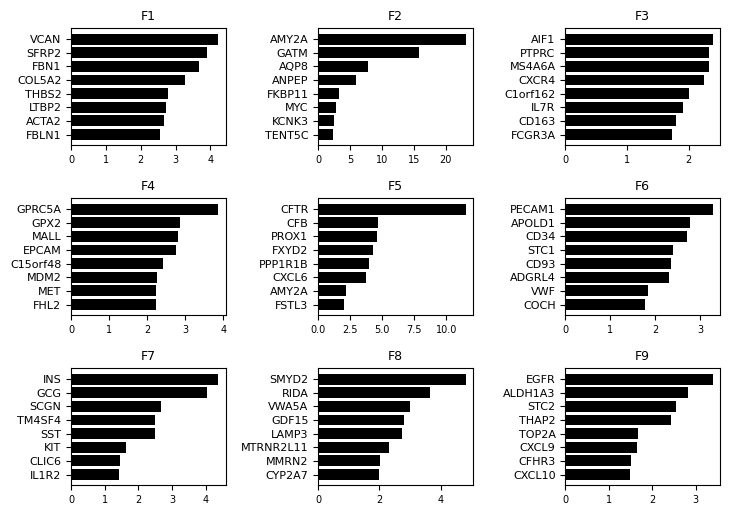

In [7]:
fit.plot_loadings();

The fitted dominant factor is now stored in `adata.obs`, so the same full-tissue cell-level plot can be used to inspect how cellAdmix factors relate to the cell annotation.

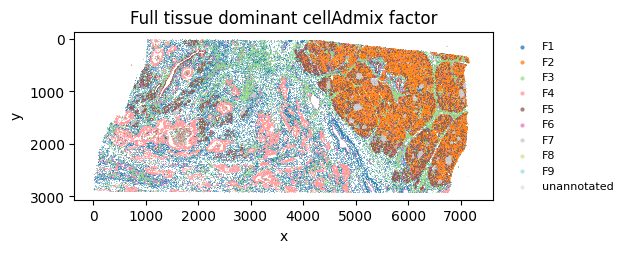

In [8]:
factor_label = pd.Series(pd.NA, index=adata.obs_names, dtype="object")
mask = adata.obs["celladmix_dominant_factor"].notna()
factor_label.loc[mask] = "F" + adata.obs.loc[mask, "celladmix_dominant_factor"].astype(int).astype(str)
adata.obs["celladmix_dominant_factor_label"] = factor_label.astype("category")

plot_cell_spatial(adata, "celladmix_dominant_factor_label", "Full tissue dominant cellAdmix factor")
plt.show()

## Membrane Scoring

Membrane scoring derives factor/source/target evidence from the membrane-focused morphology image. The heatmap marks inferred source calls with `S` and target cleanup calls with `*`.

[INFO 10:59:52 +3.072s] Starting membrane test: molecules=6186500, cells=140335 (0.000s)
[INFO 10:59:52 +3.072s] Opened membrane image: width=34155, height=13770 (0.000s)
[INFO 10:59:52 +3.204s] Prepared membrane data: cell_types=7, factors=9, active_cells=140335, typed_active_cells=125723 (0.132s)


[INFO 10:59:53 +3.968s] Discovered membrane candidates: pairs=18940 (0.763s)


[INFO 11:01:11 +81.716s] Scored membrane candidates: score_rows=35353 (77.748s)
[INFO 11:01:11 +81.721s] Summarized membrane scores: summaries=380 (0.005s)
[INFO 11:01:11 +81.721s] Finished membrane test: summaries=380 (78.649s)


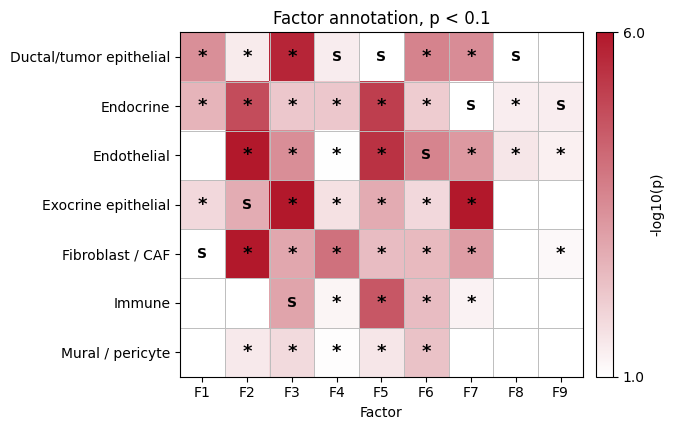

In [9]:
p_thresh = 0.1
membrane_score = fit.score_membrane(verbose=True)
rules = membrane_score.rules(p_thresh=p_thresh)
membrane_score.plot_heatmap(p_thresh=p_thresh);

Factor-specific pair plots show candidate source cell types in columns, candidate target cell types in rows, and signed significance in the heatmap body. To keep the SpatialData notebook compact, only the first four factors are shown here.

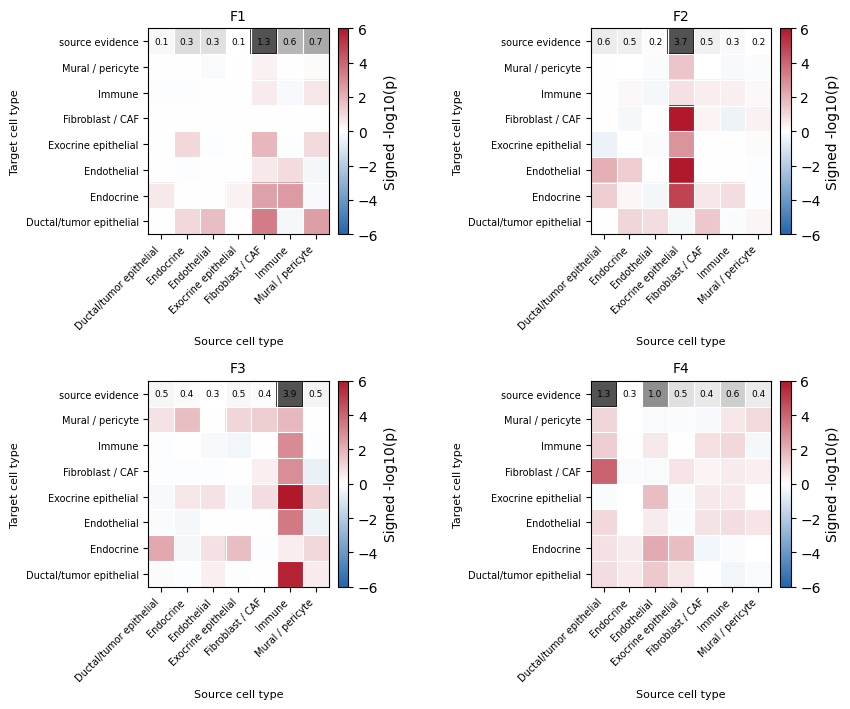

In [10]:
membrane_score.plot_pairs(factors=[1, 2, 3, 4], p_thresh=p_thresh);

The rule table is the compact representation used for correction: remove molecules assigned to a factor from a target cell type, while retaining the source cell type as interpretation.

In [11]:
rules[["factor", "source_cell_type", "target_cell_type", "p_value"]].head()

,factor,source_cell_type,target_cell_type,p_value
11,3,Immune,Exocrine epithelial,1.269443e-10
6,2,Exocrine epithelial,Fibroblast / CAF,1.481758e-10
34,7,Endocrine,Exocrine epithelial,2.127712e-10
5,2,Exocrine epithelial,Endothelial,6.779203e-07
8,3,Immune,Ductal/tumor epithelial,2.036841e-06


## Corrected Counts

Corrected counts can be inserted as an AnnData layer in the SpatialData table, keeping the matrix aligned to the existing cells and genes. This is the main integration point: downstream scverse code can use the corrected matrix by selecting the `celladmix_corrected_counts` layer.

In [12]:
correction = membrane_score.correct(rules=rules, name="membrane_clean")
add_corrected_counts_to_spatialdata(sdata, correction, table=table_name, layer="celladmix_corrected_counts")
adata.layers["celladmix_corrected_counts"].shape

(140702, 377)

For fast full-tissue visualization, we use the SpatialData table as an AnnData object and plot cell centroids. The next cell creates log-normalized original and corrected layers, then uses Scanpy's spatial embedding plot to compare marker expression before and after correction.

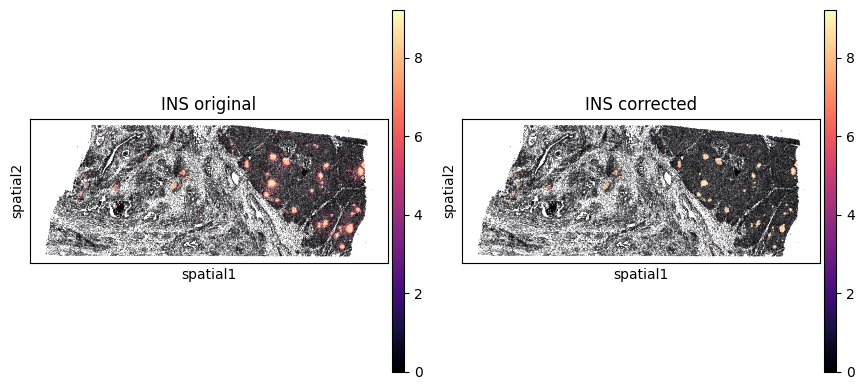

In [13]:
def add_log1p_layer(adata, source_layer, target_layer):
    working = adata.copy()
    if source_layer is not None:
        working.X = adata.layers[source_layer].copy()
    sc.pp.normalize_total(working, target_sum=1e4)
    sc.pp.log1p(working)
    adata.layers[target_layer] = working.X.copy()


add_log1p_layer(adata, None, "celladmix_original_log1p")
add_log1p_layer(adata, "celladmix_corrected_counts", "celladmix_corrected_log1p")

marker_genes = ["INS"]
fig, axes = plt.subplots(len(marker_genes), 2, figsize=(8.8, 4.0 * len(marker_genes)), squeeze=False)
for row, gene in enumerate(marker_genes):
    sc.pl.embedding(adata, basis="spatial", color=gene, layer="celladmix_original_log1p",
        ax=axes[row, 0], show=False, size=0.6, cmap="magma", title=f"{gene} original")
    sc.pl.embedding(adata, basis="spatial", color=gene, layer="celladmix_corrected_log1p",
        ax=axes[row, 1], show=False, size=0.6, cmap="magma", title=f"{gene} corrected")
    for ax in axes[row, :]:
        ax.set_aspect("equal", adjustable="box")
        ax.invert_yaxis()
fig.tight_layout()
plt.show()

We can also summarize correction magnitude back in `adata.obs` and plot it with the same cell-level scverse view.

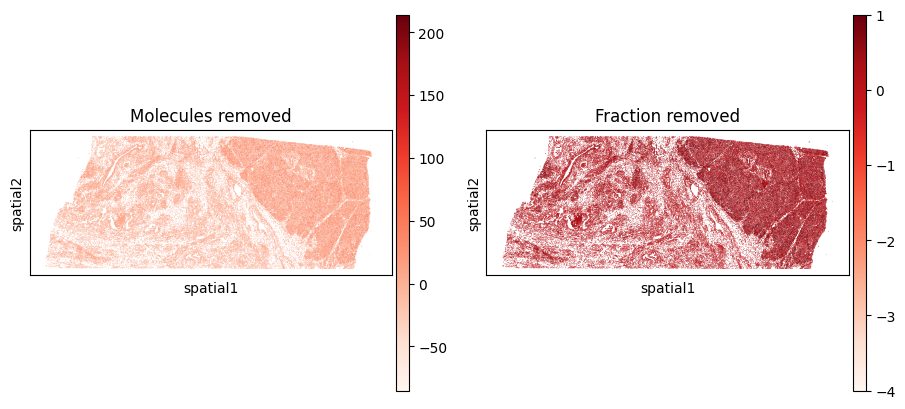

In [14]:
original_total = np.asarray(adata.X.sum(axis=1)).ravel()
corrected_total = np.asarray(adata.layers["celladmix_corrected_counts"].sum(axis=1)).ravel()
removed_total = original_total - corrected_total
adata.obs["celladmix_original_total"] = original_total
adata.obs["celladmix_corrected_total"] = corrected_total
adata.obs["celladmix_removed_total"] = removed_total
adata.obs["celladmix_fraction_removed"] = removed_total / np.maximum(original_total, 1)

fig, axes = plt.subplots(1, 2, figsize=(9.2, 4.2))
sc.pl.embedding(adata, basis="spatial", color="celladmix_removed_total", ax=axes[0],
    show=False, size=0.6, cmap="Reds", title="Molecules removed")
sc.pl.embedding(adata, basis="spatial", color="celladmix_fraction_removed", ax=axes[1],
    show=False, size=0.6, cmap="Reds", title="Fraction removed")
for ax in axes:
    ax.set_aspect("equal", adjustable="box")
    ax.invert_yaxis()
fig.tight_layout()
plt.show()

A corrected cell-level matrix can also be used for standard cell-state analysis. To keep this diagnostic fast, we subsample a balanced set of cells, then use Scanpy to compute one UMAP from original counts and one from corrected counts. These are independent embeddings rather than fixed-coordinate projections, so the exact global geometry is not expected to match the C++ helper embedding used in the standalone notebook. The table reports local annotation separation using kNN label purity in PCA space; higher normalized purity means cells have more same-annotation neighbors than expected from annotation frequencies alone.

In [15]:
def stratified_cell_subset(adata, label_col, max_cells=5000, random_state=1):
    rng = np.random.default_rng(random_state)
    labels = adata.obs[label_col].astype("object")
    valid = np.flatnonzero(labels.notna().to_numpy())
    if len(valid) <= max_cells:
        return valid
    groups = labels.iloc[valid].groupby(labels.iloc[valid], sort=True).indices
    per_group = max(1, max_cells // max(1, len(groups)))
    chosen = []
    for rel_idx in groups.values():
        idx = valid[np.asarray(rel_idx, dtype=int)]
        chosen.extend(rng.choice(idx, size=min(len(idx), per_group), replace=False).tolist())
    remaining = max_cells - len(chosen)
    if remaining > 0:
        pool = np.setdiff1d(valid, np.asarray(chosen, dtype=int), assume_unique=False)
        chosen.extend(rng.choice(pool, size=min(remaining, len(pool)), replace=False).tolist())
    return np.asarray(chosen, dtype=int)


def state_umap_from_layer(adata, layer, label_col="cell_type"):
    work = adata.copy()
    if layer is not None:
        work.X = adata.layers[layer].copy()
    sc.pp.normalize_total(work, target_sum=1e4)
    sc.pp.log1p(work)
    sc.pp.pca(work, n_comps=30, svd_solver="arpack", random_state=1)
    sc.pp.neighbors(work, n_neighbors=15, n_pcs=30, metric="cosine", random_state=1)
    sc.tl.umap(work, min_dist=0.35, random_state=1)

    labels = work.obs[label_col].astype(str).to_numpy()
    neighbors = NearestNeighbors(n_neighbors=16, metric="cosine").fit(work.obsm["X_pca"])
    neighbor_idx = neighbors.kneighbors(work.obsm["X_pca"], return_distance=False)[:, 1:]
    purity = float(np.mean(labels[neighbor_idx] == labels[:, None]))
    baseline = float(np.sum(pd.Series(labels).value_counts(normalize=True).to_numpy() ** 2))
    normalized = float((purity - baseline) / max(1e-12, 1 - baseline))
    metrics = {"knn_same_type_fraction": purity, "baseline_fraction": baseline,
        "normalized_purity": normalized}
    return work.obsm["X_umap"].copy(), metrics


state_subset_idx = stratified_cell_subset(adata, "cell_type", max_cells=5000)
state_adata = adata[state_subset_idx, :].copy()
state_adata.obsm["X_umap_original"], original_metrics = state_umap_from_layer(state_adata, None)
state_adata.obsm["X_umap_corrected"], corrected_metrics = state_umap_from_layer(
    state_adata, "celladmix_corrected_counts")

state_metrics = pd.DataFrame([original_metrics, corrected_metrics],
    index=["original", "corrected"])
state_metrics

,knn_same_type_fraction,baseline_fraction,normalized_purity
original,0.833680,0.142857,0.805960
corrected,0.912227,0.142857,0.897598


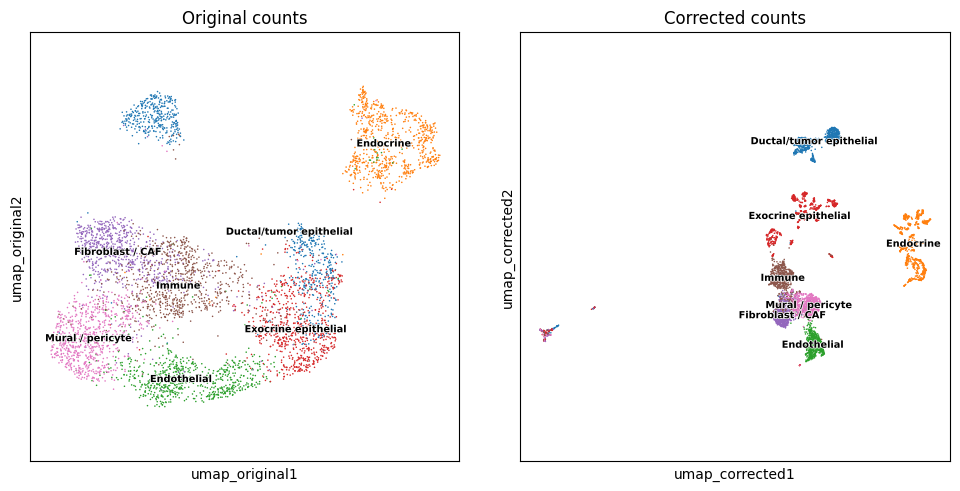

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(9.8, 4.8), constrained_layout=True)
sc.pl.embedding(state_adata, basis="umap_original", color="cell_type", ax=axes[0],
    show=False, size=5, title="Original counts", legend_loc="on data",
    legend_fontsize=7, legend_fontoutline=1)
sc.pl.embedding(state_adata, basis="umap_corrected", color="cell_type", ax=axes[1],
    show=False, size=5, title="Corrected counts", legend_loc="on data",
    legend_fontsize=7, legend_fontoutline=1)
for ax in axes:
    ax.set_aspect("equal", adjustable="box")
    ax.set_box_aspect(1)
plt.show()